In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fmcg_inventory.csv")
df.head()

,brand,name,type,size,stock_units,last_import_date,days_since_import,status
0,TH True Milk,Milk,Low fat,5L,213,2024-04-16,15,Active
1,Sabeco,Soft drink,Green tea,200g,846,2023-01-21,466,Dead stock
2,Tan Hiep Phat,Cooking oil,Vegan,100g,323,2024-02-04,87,Active
3,Neptune,Soft drink,Orange soda,180ml,268,2024-03-11,51,Active
4,Vinamilk,Soft drink,Lemon soda,5L,962,2023-10-13,201,Dead stock


In [2]:
# Summary counts
status_counts = df["status"].value_counts()
units_by_status = df.groupby("status")["stock_units"].sum()

print(status_counts)
print()
print(units_by_status)

status
Active         248
Dead stock     169
Slow moving     83
Name: count, dtype: int64

status
Active          56632
Dead stock     128439
Slow moving     19577
Name: stock_units, dtype: int64


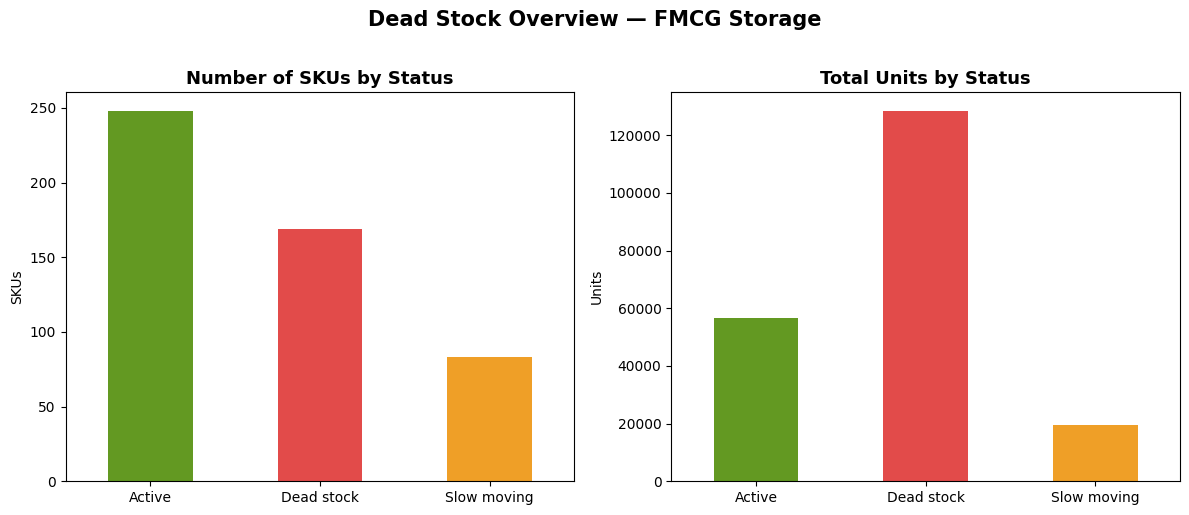

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: SKUs by status
colors = {"Active": "#639922", "Slow moving": "#EF9F27", "Dead stock": "#E24B4A"}
status_counts.plot(kind="bar", ax=axes[0], color=[colors[i] for i in status_counts.index], edgecolor="none")
axes[0].set_title("Number of SKUs by Status", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("SKUs")
axes[0].tick_params(axis="x", rotation=0)

# Chart 2: Units by status
units_by_status.plot(kind="bar", ax=axes[1], color=[colors[i] for i in units_by_status.index], edgecolor="none")
axes[1].set_title("Total Units by Status", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Units")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Dead Stock Overview — FMCG Storage", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart_overview.png", dpi=150, bbox_inches="tight")
plt.show()

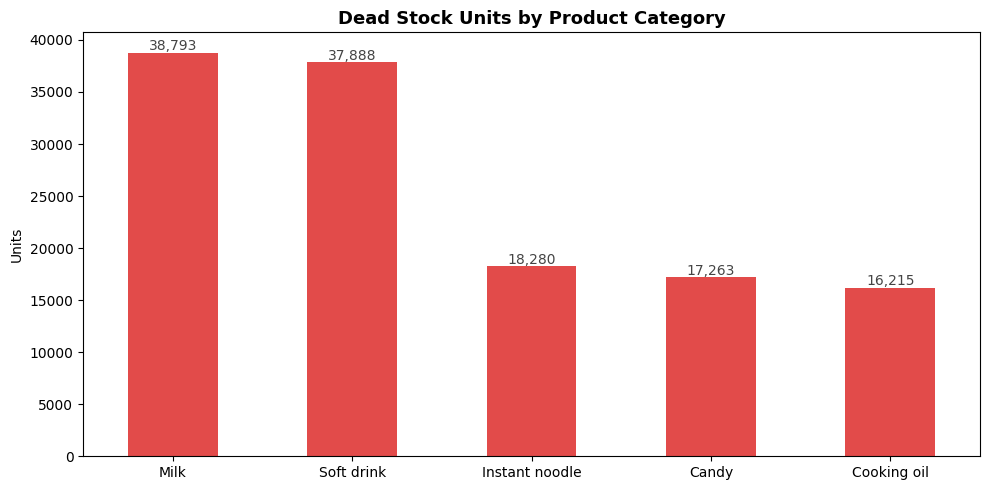

In [4]:
dead = df[df["status"] == "Dead stock"]
dead_by_category = dead.groupby("name")["stock_units"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
dead_by_category.plot(kind="bar", ax=ax, color="#E24B4A", edgecolor="none")
ax.set_title("Dead Stock Units by Product Category", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Units")
ax.tick_params(axis="x", rotation=0)

for i, v in enumerate(dead_by_category):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=10, color="#444")

plt.tight_layout()
plt.savefig("chart_dead_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


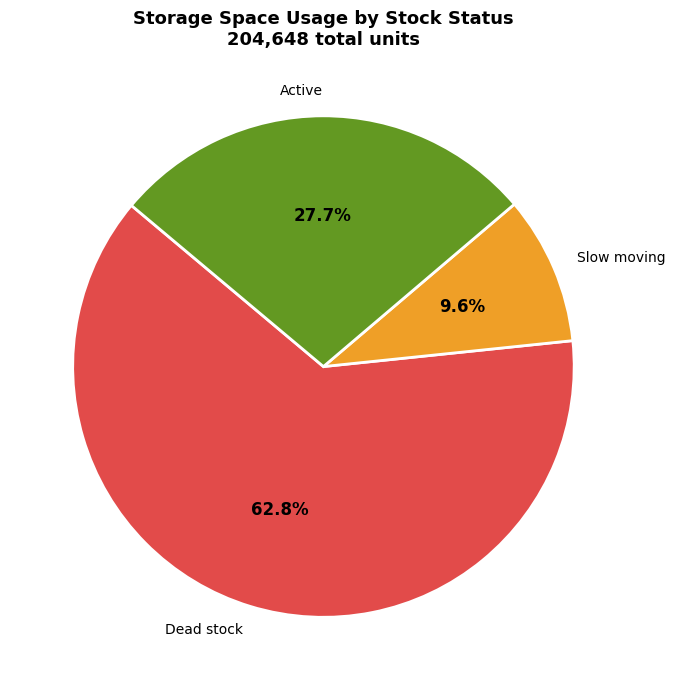

In [5]:
waste_data = {
    "Dead stock": 128439,
    "Slow moving": 19577,
    "Active": 56632
}

colors = ["#E24B4A", "#EF9F27", "#639922"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    waste_data.values(),
    labels=waste_data.keys(),
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight("bold")

ax.set_title("Storage Space Usage by Stock Status\n204,648 total units", 
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("chart_space_waste.png", dpi=150, bbox_inches="tight")
plt.show()
